# SmartCart Day 5a - Assemble + ONNX (SG edition)

Wire the whole pipeline together - detector -> crops -> features -> head + catalog search - then **export the head to ONNX**, prove numerical parity, and quantize it for deployment in Day 5b's app.

Adapted from Hongming's `Day5a_assemble_onnx_updated.ipynb` (confidence scoring via `score_feat()`, `CONFIDENCE_THRESHOLD` gating, needs-review flags) with three changes: (1) runs **locally** against `~/SmartCart_bundle` instead of Colab/Drive, (2) serves the **25-class Singapore catalog** with real SGD prices (the bundle Day 1-4 built), and (3) the confidence threshold is **calibrated on real detector crops** below instead of the 0.5 placeholder.

In [1]:
# 1) Runtime setup
%pip install -q timm ultralytics onnx onnxruntime

import os

# The cross-day bundle lives in a local folder (was a Google Drive mount on Colab).
# Day 1-4 write to this same path for continuity.
BUNDLE_DIR = os.path.expanduser('~/SmartCart_bundle')



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3.13 install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


### Embedded toolkit

This cell defines the helper functions used below. Run it once after setup.

In [2]:
from __future__ import annotations
import json
import os
import pathlib
import subprocess
import numpy as np
import pandas as pd
HERE = pathlib.Path.cwd()  # embedded in-notebook: no __file__, anchor on the working dir

class Bundle:
    """Small local folder that carries artifacts from one day to the next."""

    def __init__(self, root: str):
        self.root = pathlib.Path(root)
        self.root.mkdir(parents=True, exist_ok=True)
        self.manifest = {'version': 1, 'class_list': [], 'artifacts': {}}

    def put_table(self, name, df: pd.DataFrame):
        df.to_csv(self.root / name, index=False)
        self._note(name)

    def get_table(self, name) -> pd.DataFrame:
        return pd.read_csv(self.root / name)

    def put_array(self, name, arr: np.ndarray):
        np.save(self.root / name, arr)
        self._note(name)

    def get_array(self, name) -> np.ndarray:
        p = self.root / name
        return np.load(p if p.suffix == '.npy' else p.with_suffix('.npy'))

    def _note(self, name):
        self.manifest['artifacts'][name] = True

    def save(self):
        (self.root / 'manifest.json').write_text(json.dumps(self.manifest, indent=2))

    def load(self):
        p = self.root / 'manifest.json'
        if p.exists():
            self.manifest = json.loads(p.read_text())
        return self

def open_bundle(drive_dir=None) -> Bundle:
    """Open the cross-day local bundle. If it is new, start with an empty manifest."""
    return Bundle(drive_dir or os.path.expanduser('~/SmartCart_bundle')).load()

def save_bundle(b: Bundle):
    b.save()
    print(f'[bundle] saved -> {b.root}')

def load_backbone(name='vit_small_patch14_dinov2.lvd142m', device='cpu'):
    """Frozen DINOv2-small feature extractor."""
    import timm
    m = timm.create_model(name, pretrained=True, num_classes=0, dynamic_img_size=True).eval().to(device)
    for p in m.parameters():
        p.requires_grad_(False)
    return m

def extract_features(model, batches, device=None) -> np.ndarray:
    """Run image batches through a frozen backbone and return numpy features."""
    import torch
    if device is None:
        try:
            device = next(model.parameters()).device
        except (AttributeError, StopIteration):
            device = 'cpu'
    outs = []
    with torch.no_grad():
        for xb in batches:
            y = model(xb.to(device))
            outs.append(y.detach().cpu().numpy().astype('float32'))
    return np.concatenate(outs, 0)

class EmbeddingIndex:
    """Cosine nearest-neighbor index over catalog/gallery embeddings."""

    def __init__(self):
        self._nn = None
        self.meta = []

    def build(self, feats: np.ndarray, meta: list[dict]):
        from sklearn.neighbors import NearestNeighbors
        f = feats / (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-08)
        self._nn = NearestNeighbors(n_neighbors=min(10, len(f)), metric='cosine').fit(f)
        self.meta = meta
        self._feats = f
        return self

    def query(self, q: np.ndarray, k=5):
        qn = q / (np.linalg.norm(q, axis=1, keepdims=True) + 1e-08)
        dist, idx = self._nn.kneighbors(qn, n_neighbors=min(k, len(self.meta)))
        return [[{**self.meta[j], 'score': float(1 - d)} for d, j in zip(drow, irow)] for drow, irow in zip(dist, idx)]

    def save(self, b: Bundle, prefix='gallery'):
        b.put_array(f'{prefix}_index.npy', self._feats)
        b.put_table(f'{prefix}_meta.csv', pd.DataFrame(self.meta))

    @classmethod
    def load(cls, b: Bundle, prefix='gallery'):
        feats = b.get_array(f'{prefix}_index.npy')
        meta = b.get_table(f'{prefix}_meta.csv').to_dict('records')
        return cls().build(feats, meta)

def basket_total(items, prices, default=0.0):
    return float(sum((prices.get(it['fine'], default) for it in items)))

class LinearHead:
    """Tiny torch linear classifier trained on frozen image features."""

    def __init__(self, in_dim, n_classes):
        import torch
        import torch.nn as nn
        self.net = nn.Linear(in_dim, n_classes)
        self.torch = torch

    def fit(self, X, y, epochs=30, lr=0.01):
        t = self.torch
        opt = t.optim.Adam(self.net.parameters(), lr=lr)
        lossf = t.nn.CrossEntropyLoss()
        Xt = t.tensor(X)
        yt = t.tensor(y)
        for _ in range(epochs):
            opt.zero_grad()
            loss = lossf(self.net(Xt), yt)
            loss.backward()
            opt.step()
        return self

    def predict(self, X):
        with self.torch.no_grad():
            return self.net(self.torch.tensor(X)).argmax(1).numpy()

def load_head(path) -> LinearHead:
    import torch
    ckpt = torch.load(path, map_location='cpu')
    head = LinearHead(ckpt['in_dim'], ckpt['n_classes'])
    head.net.load_state_dict(ckpt['state_dict'])
    head.net.eval()
    return head

def export_head_onnx(head: LinearHead, in_dim, path):
    import torch
    torch.onnx.export(head.net, torch.zeros(1, in_dim), path, input_names=['feat'], output_names=['logits'], dynamic_axes={'feat': {0: 'n'}, 'logits': {0: 'n'}}, opset_version=17, dynamo=False)
    return path

def onnx_parity(head, onnx_path, x):
    import onnxruntime as ort
    ref = head.net(head.torch.tensor(x)).detach().numpy()
    got = ort.InferenceSession(onnx_path).run(None, {'feat': x})[0]
    return float(np.abs(ref - got).max())

def score_feat(feat, head, classes):
    """Softmax-confidence scoring for an already-embedded feature vector
    (Hongming's addition) - the pipeline below already has the crop's embedding
    in memory, so we score it directly instead of re-running the backbone."""
    logits = head.net(head.torch.tensor(feat)).detach().numpy()[0]
    probs = np.exp(logits - logits.max())
    probs = probs / probs.sum()
    pred_id = int(np.argmax(logits))
    return {'pred_id': pred_id, 'pred_name': classes[pred_id], 'confidence': float(probs[pred_id])}

# Placeholder until the calibration cell below computes a data-driven value.
CONFIDENCE_THRESHOLD = 0.5

print('SmartCart toolkit ready')


SmartCart toolkit ready


In [3]:
# 2) Load the cross-day bundle
b = open_bundle(BUNDLE_DIR)
print('bundle:', b.root)
print('artifacts:', list(b.manifest.get('artifacts', {})))


bundle: /home/jonyling/SmartCart_bundle
artifacts: ['sample_scene.jpg', 'detector.pt', 'crops_manifest.csv', 'gallery_index.npy', 'gallery_meta.csv', 'catalog_prices.csv', 'labels.csv', 'head.pt', 'per_class_metrics.csv', 'error_report.md', 'head_v2.pt', 'lift_table.csv', 'lift_table_vs_real_photo.csv', 'decisive_lift_table.csv', 'confidence_threshold.json', 'head.onnx', 'crops_train.csv', 'calibration_crops.csv']


## Load everything

**What:** Load the best head (v2 if present), the gallery index, and the backbone.

**Why:** Day 5 consumes every artifact the week produced - this is the integration point.

**Watch for:** `head_v2.pt` is the Day 4 head trained with copy-paste augmentation (the one that scored 80% on real photos vs 51% baseline) - prefer it.

In [4]:
from pathlib import Path
import torch
# Deploy whichever improved head is NEWEST (Huimin's design): head_v3 is the
# corrections-retrained head from Day 3's self-improvement loop (it may have MORE
# classes than the original catalog, so it ships with its own class_list_v3.json);
# head_v2 is Day 4's augmentation-improved head; head.pt is Day 3's baseline.
if (Path(b.root)/'head_v3.pt').exists():
    head = load_head(str(Path(b.root)/'head_v3.pt'))
    classes = json.loads((Path(b.root)/'class_list_v3.json').read_text())
    b.manifest['class_list'] = classes  # demos read class_list; persisted by the save cell below
    print(f'deploying head_v3 (corrections-retrained, newest) - {len(classes)} classes')
elif (Path(b.root)/'head_v2.pt').exists():
    head = load_head(str(Path(b.root)/'head_v2.pt'))
    classes = b.manifest.get('class_list') or None
    print('deploying head_v2 (Day 4 augmentation-improved)')
else:
    head = load_head(str(Path(b.root)/'head.pt'))
    classes = b.manifest.get('class_list') or None
    print('deploying head.pt (Day 3 baseline)')
idx = EmbeddingIndex.load(b)
if classes is None:
    classes = sorted({m['fine'] for m in idx.meta})
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('using device:', device)
model = load_backbone(device=device)
price_catalog = b.get_table('catalog_prices.csv')
prices = dict(zip(price_catalog.fine, price_catalog.unit_price))
currency = price_catalog.currency.iloc[0] if 'currency' in price_catalog else 'USD'
assert head.net.out_features == len(classes), \
    f'head/classes mismatch: head has {head.net.out_features} outputs, class_list has {len(classes)} - rerun Day 1-4 on the same catalog'
print('loaded head, gallery index, price catalog, backbone -', len(classes), 'classes, prices in', currency)


deploying head_v2 (Day 4 augmentation-improved)


using device: cuda


/home/jonyling/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded head, gallery index, price catalog, backbone - 25 classes, prices in SGD


## Calibrate the confidence threshold (replaces the 0.5 placeholder)

**What:** Sweep candidate thresholds on Day 2's **real detector crops** (the closest thing we have to production inputs - YOLO-cropped, off-center, sometimes clipped) and pick the smallest threshold whose auto-accepted predictions are >=95% accurate.

**Why:** Hongming's notebooks flagged `CONFIDENCE_THRESHOLD = 0.5` as "a placeholder, not a validated cutoff" and referenced a `evaluate_confidence_thresholds()` sweep that didn't exist yet - this cell is that sweep, realized. A threshold set too low silently ships wrong prices; too high drowns the cashier in review flags.

**Watch for:** The chosen threshold is saved to the bundle (`confidence_threshold.json`) so Day 5b serves with the **same** calibrated value.

In [5]:
import torch, torchvision.transforms.v2 as T
from PIL import Image
# Shared image preprocessing for DINOv2.
TF = T.Compose([T.ToImage(), T.Resize((224,224)), T.ToDtype(torch.float32, scale=True),
                T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
def feats_of(paths, model, bs=16):
    out=[]
    for i in range(0,len(paths),bs):
        xs=torch.stack([TF(Image.open(p).convert('RGB')) for p in paths[i:i+bs]])
        out.append(extract_features(model,[xs]))
    return np.concatenate(out,0)

# Calibrate ONLY on crops the heads never trained on. Day 3's crop-aware retraining
# saves a held-out 30% split as calibration_crops.csv for exactly this purpose -
# calibrating on the full crops_manifest.csv (which Day 3/4 train on) shows ~100%
# accuracy at every threshold (the head memorized them) and picks a uselessly low
# cutoff. That leakage actually happened in an earlier run; the split fixes it.
try:
    crops = b.get_table('calibration_crops.csv')
    cal_source = 'calibration_crops.csv (held out from crop-aware training)'
except Exception:
    crops = b.get_table('crops_manifest.csv')
    cal_source = 'crops_manifest.csv (WARNING: heads may have trained on these - sweep is optimistic)'
crops = crops[crops.crop_path.apply(os.path.exists) & crops.fine.isin(classes)].reset_index(drop=True)
print('calibration set:', cal_source)
cf = feats_of(list(crops.crop_path), model)
with torch.no_grad():
    logits = head.net(torch.tensor(cf)).numpy()
probs = np.exp(logits - logits.max(axis=1, keepdims=True)); probs /= probs.sum(axis=1, keepdims=True)
conf, pred = probs.max(axis=1), probs.argmax(axis=1)
truth = np.array([classes.index(f) for f in crops.fine])

rows = []
for t in np.arange(0.05, 1.0, 0.05):
    accept = conf >= t
    rows.append({'threshold': round(float(t),2),
                 'coverage': round(float(accept.mean()),3),
                 'acc_on_accepted': round(float((pred[accept]==truth[accept]).mean()),3) if accept.any() else float('nan'),
                 'flagged_for_review': int((~accept).sum())})
sweep = pd.DataFrame(rows)
print(f'sweep over {len(crops)} held-out detector crops:')
print(sweep.to_string(index=False))

# 0.98, not 0.95: the serving head is now accurate enough in-domain (96%+ on all
# held-out crops) that a 95% target is met at every threshold and the rule degenerates
# to picking the minimum. 0.98 selects the sweep's elbow instead. KNOWN LIMIT: this
# gate is calibrated on composed-scene crops; on real phone photos the head is still
# overconfident (wrong predictions at 0.8-0.9 confidence pass) - fixing that needs a
# real-photo calibration set, i.e. more team photos from the next store visit.
TARGET_ACC = 0.98
ok = sweep[sweep.acc_on_accepted >= TARGET_ACC]
if len(ok):
    CONFIDENCE_THRESHOLD = float(ok.threshold.iloc[0])
    print(f'\ncalibrated CONFIDENCE_THRESHOLD = {CONFIDENCE_THRESHOLD} '
          f'(smallest threshold with accepted-accuracy >= {TARGET_ACC:.0%})')
else:
    print(f'\nno threshold reaches {TARGET_ACC:.0%} accepted-accuracy; keeping fallback {CONFIDENCE_THRESHOLD}')
(Path(b.root)/'confidence_threshold.json').write_text(json.dumps(
    {'threshold': CONFIDENCE_THRESHOLD, 'calibrated_on': cal_source,
     'n_crops': int(len(crops)), 'target_acc': TARGET_ACC}))
b._note('confidence_threshold.json')


calibration set: calibration_crops.csv (held out from crop-aware training)


sweep over 52 held-out detector crops:
 threshold  coverage  acc_on_accepted  flagged_for_review
      0.05     1.000            0.962                   0
      0.10     1.000            0.962                   0
      0.15     1.000            0.962                   0
      0.20     1.000            0.962                   0
      0.25     1.000            0.962                   0
      0.30     1.000            0.962                   0
      0.35     1.000            0.962                   0
      0.40     1.000            0.962                   0
      0.45     1.000            0.962                   0
      0.50     1.000            0.962                   0
      0.55     1.000            0.962                   0
      0.60     0.981            0.980                   1
      0.65     0.962            0.980                   2
      0.70     0.962            0.980                   2
      0.75     0.962            0.980                   2
      0.80     0.962            0

## Assemble the pipeline on one photo

**What:** Detect products in a scene, crop them, embed, classify with the head, and look up the catalog. Confidence is checked here (Hongming's addition): low-confidence items get an orange box, a `?` label, and a `needs_review` flag.

**Why:** This is the end-to-end SmartCart inference path in one cell - the thing we actually ship.

**Watch for:** Uses `sample_scene.jpg` from Day 2 by default; point `TEST_IMAGE` at any photo - e.g. a real one from `../sg_data/sg_dataset/natural/`.

using image: /home/jonyling/SmartCart_bundle/sample_scene.jpg


detector boxes: 2 conf: [0.29499998688697815, 0.054999999701976776]
assembled pipeline on 2 detections


,predicted_item,confidence,needs_review,unit_price,currency,similar_gallery_matches
0,Prima-Taste-Laksa,1.0,False,9.79,SGD,"[Marigold-HL-Milk, Pasar-Fresh-Eggs, Prima-Tas..."
1,Prima-Taste-Laksa,1.0,False,9.79,SGD,"[Marigold-HL-Milk, Pasar-Fresh-Eggs, FN-Seasons]"


estimated basket total: 19.58 SGD (includes best-guess price for flagged items)


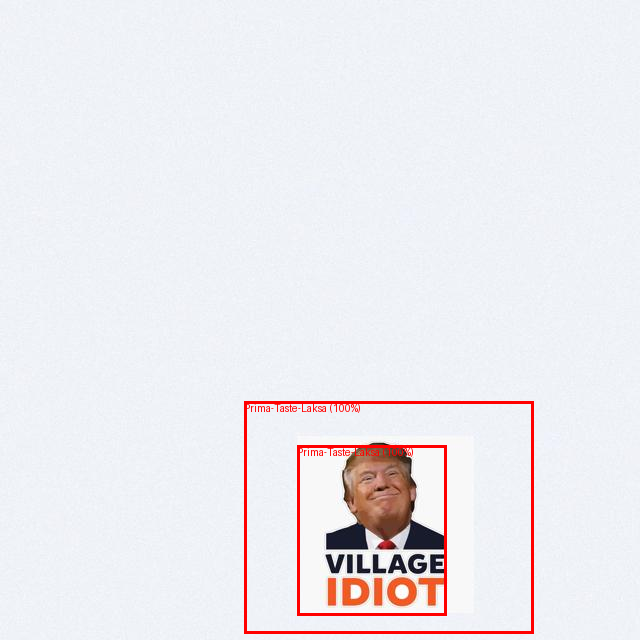

In [6]:
from ultralytics import YOLO
from PIL import Image, ImageDraw
def feats_of_imgs(imgs, model):
    """Embed PIL crops already in memory."""
    xs = torch.stack([TF(im.convert('RGB')) for im in imgs])
    return extract_features(model, [xs])
det = YOLO(str(Path(b.root)/'detector.pt'))
# Choose the input style:
# - 'multi_item_scene': use YOLO boxes from a cart/counter image.
# - 'single_product': skip YOLO and classify the whole image.
# - 'auto': use YOLO, but fall back to whole image if no boxes are found.
INPUT_MODE = 'auto'
TEST_IMAGE = ''  # set to any local photo path; empty -> Day 2's sample_scene.jpg
scene_path = TEST_IMAGE or str(Path(b.root)/'sample_scene.jpg')
assert Path(scene_path).exists(), f'Image not found: {scene_path}. If using the default sample, re-run Day 2.'
print('using image:', scene_path)
img = Image.open(scene_path).convert('RGB'); arr = np.array(img)
if INPUT_MODE == 'single_product':
    print('single_product mode: skipping detector and using the whole image.')
    boxes = np.array([[0, 0, img.width, img.height]], dtype='float32')
else:
    result = det(scene_path, imgsz=640, conf=0.05, verbose=False)[0]
    boxes = result.boxes.xyxy.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy() if len(result.boxes) else []
    print('detector boxes:', len(boxes), 'conf:', np.round(confs, 3).tolist())
    if len(boxes) == 0 and INPUT_MODE == 'auto':
        print('No detector boxes found; using the whole image as one product crop.')
        boxes = np.array([[0, 0, img.width, img.height]], dtype='float32')
if len(boxes):
    areas = (boxes[:,2]-boxes[:,0]) * (boxes[:,3]-boxes[:,1])
    largest = float(areas.max() / (img.width * img.height))
    if INPUT_MODE == 'auto' and largest < 0.10:
        print('Only small boxes were found. If this is a single product photo, set INPUT_MODE = "single_product".')
draw = ImageDraw.Draw(img)
# For each detected product: crop -> embed -> classify -> lookup similar catalog images + price.
# Confidence is checked here, not just predicted - this is the one place in the whole
# pipeline that decides what the user actually sees.
rows, items = [], []
for x1,y1,x2,y2 in boxes:
    crop = Image.fromarray(arr[int(y1):int(y2), int(x1):int(x2)])
    f = feats_of_imgs([crop], model)
    s = score_feat(f, head, classes)
    pred = s['pred_name']
    needs_review = s['confidence'] < CONFIDENCE_THRESHOLD
    similar = [h['fine'] for h in idx.query(f, k=3)[0]]
    items.append({'fine': pred})
    rows.append({'predicted_item': pred, 'confidence': round(s['confidence'], 3), 'needs_review': needs_review,
                 'unit_price': prices.get(pred, 0.0), 'currency': currency, 'similar_gallery_matches': similar})
    label = f"{pred} ({s['confidence']:.0%})" + (' ?' if needs_review else '')
    box_color = 'orange' if needs_review else 'red'
    draw.rectangle([x1,y1,x2,y2], outline=box_color, width=3); draw.text((x1,y1), label, fill=box_color)
print('assembled pipeline on', len(boxes), 'detections')
display(pd.DataFrame(rows))
n_review = sum(r['needs_review'] for r in rows)
if n_review:
    print(f'{n_review} item(s) below the confidence threshold ({CONFIDENCE_THRESHOLD:.0%}) - flagged for manual review')
print('estimated basket total:', round(basket_total(items, prices, default=1.0), 2), currency, '(includes best-guess price for flagged items)')
img


## Export to ONNX

**What:** Export the linear head to ONNX (input 'feat', output 'logits').

**Why:** ONNX runs the classifier without PyTorch - smaller runtime, portable to many targets.

In [7]:
p = export_head_onnx(head, in_dim=384, path=str(Path(b.root)/'head.onnx'))
print('exported', p)


exported /home/jonyling/SmartCart_bundle/head.onnx


## Parity check

**What:** Feed a random batch through both PyTorch and ONNX and assert they match (tolerance 1e-3).

In [8]:
x = np.random.randn(2, 384).astype('float32')
err = onnx_parity(head, p, x)
assert err < 1e-3, f'parity too loose: {err}'
print('parity', err)


parity 1.430511474609375e-06


## Quantize + benchmark

**What:** Dynamically quantize the ONNX head to int8 and time torch vs onnx vs int8.

In [9]:
import time, os
sizes = {'onnx_fp32': os.path.getsize(p)}
int8_path = str(Path(b.root)/'head.int8.onnx')
try:
    from onnxruntime.quantization import quantize_dynamic, QuantType
    quantize_dynamic(p, int8_path, weight_type=QuantType.QInt8)
    sizes['onnx_int8'] = os.path.getsize(int8_path)
except Exception as e:
    print('quantization skipped:', e)
print('sizes (bytes):', sizes)
import onnxruntime as ort
sess = ort.InferenceSession(p)
xb = np.random.randn(8, 384).astype('float32')
def bench(fn, n=200):
    t0 = time.perf_counter()
    for _ in range(n): fn()
    return (time.perf_counter()-t0)/n*1e3
print('torch  ms/call:', round(bench(lambda: head.net(head.torch.tensor(xb))), 3))
print('onnx   ms/call:', round(bench(lambda: sess.run(None, {'feat': xb})), 3))
if 'onnx_int8' in sizes:
    s8 = ort.InferenceSession(int8_path)
    print('int8   ms/call:', round(bench(lambda: s8.run(None, {'feat': xb})), 3))


sizes (bytes): {'onnx_fp32': 38719, 'onnx_int8': 10609}
torch  ms/call: 0.04
onnx   ms/call: 0.029
int8   ms/call: 0.026


## Save + carry forward

**What:** Note the ONNX artifact and the calibrated threshold, save the bundle.

**Why:** Day 5b loads `head.onnx` + `confidence_threshold.json` to serve predictions inside the Gradio app.

In [10]:
b._note('head.onnx')
save_bundle(b)
print('Carries forward to Day 5b: head.onnx + confidence_threshold.json')


[bundle] saved -> /home/jonyling/SmartCart_bundle
Carries forward to Day 5b: head.onnx + confidence_threshold.json
